# **EDA univariado**
### **Carga de datos**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta_datos_limpios = '../data/datos_limpios.csv'
df = pd.read_csv(ruta_datos_limpios)

### **Información general del dataset**

In [3]:
# Dimensiones
print(f"Número de filas (niños): {df.shape[0]}")
print(f"Número de columnas (variables): {df.shape[1]}")

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes.value_counts())

# Estadísticas básicas de variables numéricas
print("\nResumen estadístico de variables numéricas:")
display(df.describe())

# Estadísticas básicas de variables categóricas
print("\nResumen de variables categóricas:")
display(df.describe(include=['object']))

Número de filas (niños): 45932
Número de columnas (variables): 39

Tipos de datos:
float64    25
int64       8
object      6
Name: count, dtype: int64

Resumen estadístico de variables numéricas:


,location_id,age,gender,geography,financial_situation,education,employment_status,edu_students,ch_gender,ch_no_school_why,...,ch_remote_method_5,ch_help_3,ch_help_1,ch_help_4,ch_help_5,ch_help_6,ch_help_2,ch_help_0,ch_help_99,child_number
count,45932.00000,45932.000000,45932.00000,45932.000000,45932.000000,45932.000000,45932.000000,45932.000000,45932.000000,3061.000000,...,22102.000000,22091.000000,22091.000000,22091.000000,22091.000000,22091.000000,22091.000000,22091.000000,22091.000000,45932.000000
mean,129.77323,2.730798,6.18449,2.004376,14.815488,13.799791,13.701428,2.801141,0.529326,12.796472,...,0.023889,0.210629,0.370875,0.127518,0.113078,0.057761,0.286316,0.223802,0.538274,1.773861
std,65.96664,1.830607,21.19311,3.906564,30.006261,14.490843,4.749164,1.604581,0.588132,29.712524,...,0.152708,0.407764,0.483050,0.333560,0.316695,0.233296,0.452049,0.416800,0.498544,0.927473
min,10.00000,2.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,102.00000,2.000000,1.00000,1.000000,3.000000,10.000000,11.000000,2.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,141.00000,2.000000,1.00000,2.000000,5.000000,12.000000,14.000000,2.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
75%,179.00000,3.000000,2.00000,3.000000,6.000000,14.000000,15.000000,4.000000,1.000000,4.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000
max,217.00000,99.000000,99.00000,99.000000,99.000000,99.000000,99.000000,9.000000,2.000000,99.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000



Resumen de variables categóricas:


,country,observation_id,user_id,submission_time,religion,ch_support
count,45932,45932,45932,45894,45932,25016
unique,51,23007,23007,22985,80,3
top,Philippines,edu_6116795667972096,edu_5986846446452736,2021-05-28 20:54:46.803000+00:00,Christian (Other),received remedial support organized by school
freq,6313,4,4,4,8290,12433


### **Distribución de `ch_age` (edad del niño)**

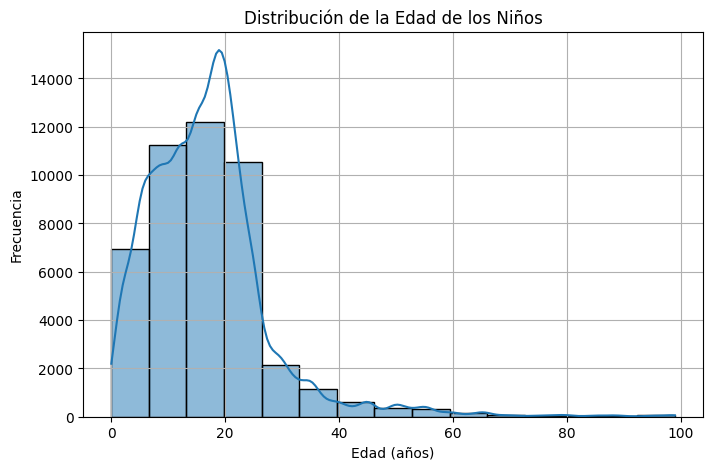

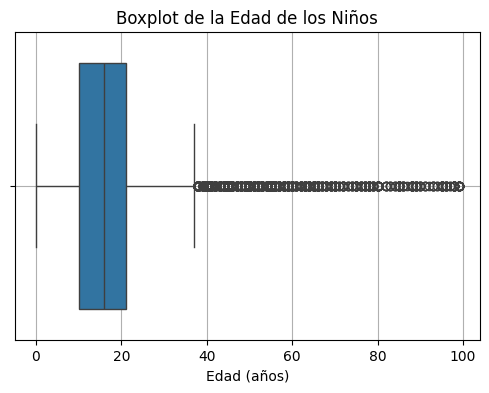

count    45932.000000
mean        16.852143
std         11.027400
min          0.000000
25%         10.000000
50%         16.000000
75%         21.000000
max         99.000000
Name: ch_age, dtype: float64


In [4]:
# Histograma de edades de niños
plt.figure(figsize=(8,5))
sns.histplot(df['ch_age'], bins=15, kde=True)
plt.title('Distribución de la Edad de los Niños')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# Boxplot para detectar posibles outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['ch_age'])
plt.title('Boxplot de la Edad de los Niños')
plt.xlabel('Edad (años)')
plt.grid(True)
plt.show()

# Resumen estadístico de ch_age
print(df['ch_age'].describe())

Se eliminarán registros de niños con edad mayor a 30 años para mantener la coherencia con la población objetivo (niños y adolescentes en edad escolar).

In [5]:
df = df[df['ch_age'] <= 30]

df.reset_index(drop=True, inplace=True)

print("Nuevas dimensiones del dataset:", df.shape)

Nuevas dimensiones del dataset: (42600, 39)


### **Nueva distribución de `ch_age`**

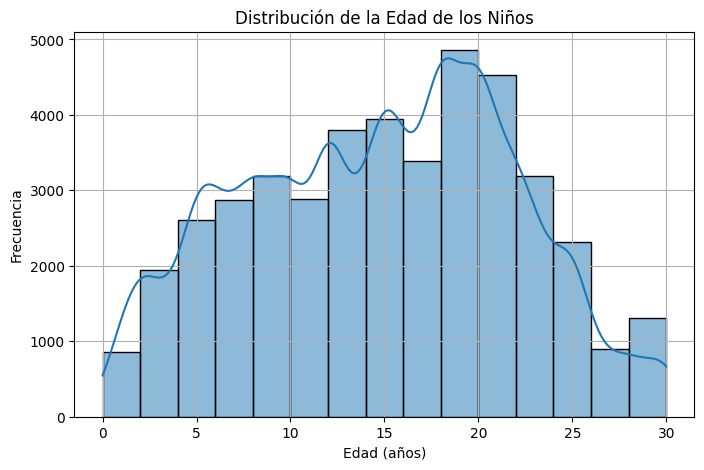

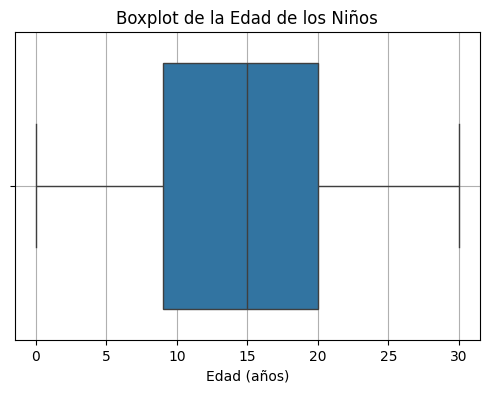

count    42600.000000
mean        14.687271
std          7.120327
min          0.000000
25%          9.000000
50%         15.000000
75%         20.000000
max         30.000000
Name: ch_age, dtype: float64


In [6]:
# Nuevo histograma
plt.figure(figsize=(8,5))
sns.histplot(df['ch_age'], bins=15, kde=True)
plt.title('Distribución de la Edad de los Niños')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# Nuevo Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['ch_age'])
plt.title('Boxplot de la Edad de los Niños')
plt.xlabel('Edad (años)')
plt.grid(True)
plt.show()

# Nuevo resumen estadístico de ch_age
print(df['ch_age'].describe())

### **Distribución de `age` (edad del cuidador)**

In [7]:
# Mapear age a etiquetas
mapa_age = {
    1: 'Under 16',
    2: '16-25',
    3: '26-35',
    4: '36-45',
    5: 'Over 45',
    99: 'Not Available'
}

df['age_label'] = df['age'].map(mapa_age)

# Crear un dataframe de cuidadores únicos
df_cuidadores = df[['user_id', 'age', 'age_label']].drop_duplicates(subset='user_id')

print('Información de cuidadores únicos:')
print(df_cuidadores['age_label'].value_counts())

Información de cuidadores únicos:
age_label
16-25            11035
26-35             7148
36-45             2482
Over 45           1089
Not Available        4
Name: count, dtype: int64


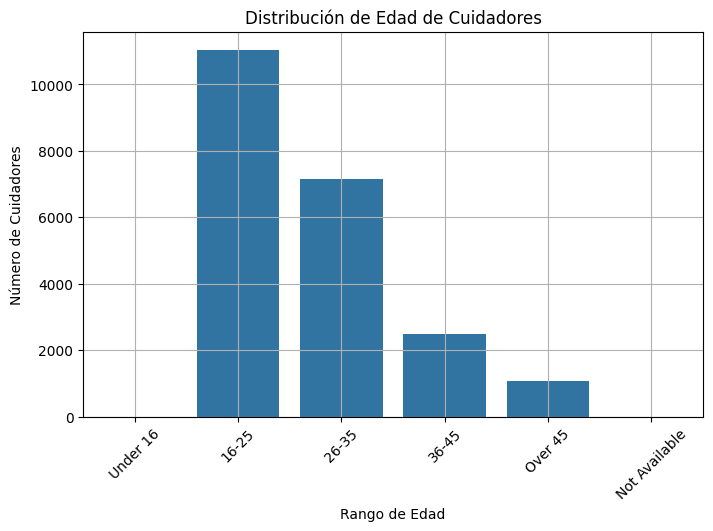

In [8]:
# Gráfica de distribución de edad de cuidadores

plt.figure(figsize=(8,5))
sns.countplot(data=df_cuidadores, x='age_label', order=['Under 16', '16-25', '26-35', '36-45', 'Over 45', 'Not Available'])
plt.title('Distribución de Edad de Cuidadores')
plt.xlabel('Rango de Edad')
plt.ylabel('Número de Cuidadores')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

El perfil de cuidador es joven (entre 16-35 años). Tenemos solo 4 casos de edad no disponible (Not Available), irrelevante estadísticamente. No habrá ningún cambio con esta variable.

### **Distribución de `ch_gender` (género del niño)**

In [9]:
# Mapeo de códigos a etiquetas
mapa_ch_gender = {
    0: 'male',
    1: 'female',
    2: 'non-binary',
    88: 'prefer_not_to_say'
}

df['ch_gender_label'] = df['ch_gender'].map(mapa_ch_gender)

print('Información de género de los niños')
print(df['ch_gender_label'].value_counts())

Información de género de los niños
ch_gender_label
male          22322
female        18375
non-binary     1903
Name: count, dtype: int64


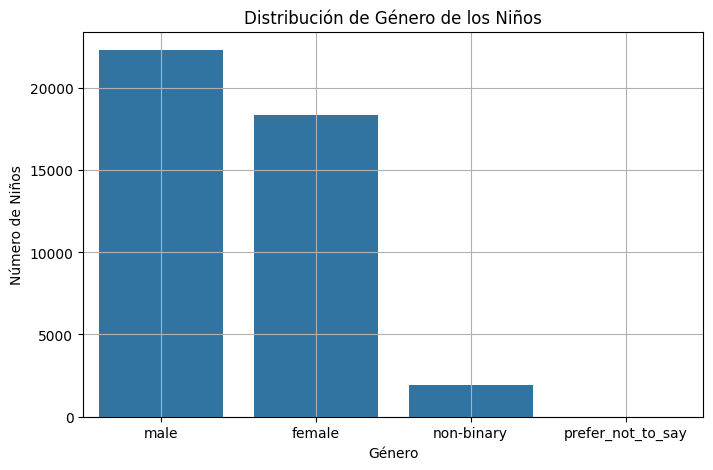

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='ch_gender_label', order=['male', 'female', 'non-binary', 'prefer_not_to_say'])
plt.title('Distribución de Género de los Niños')
plt.xlabel('Género')
plt.ylabel('Número de Niños')
plt.grid(True)
plt.show()

Se presenta una distribución casi homogénea entre niños de género masculino y femenino.

### **Distribución de `ch_school_type` (tipo de institución educativa, febrero 2020)**

In [11]:
# Mapeo a etiquetas legibles
mapa_ch_school_type = {
    1: 'public',
    2: 'private'
}

df['ch_school_type_label'] = df['ch_school_type'].map(mapa_ch_school_type)

print("Distribución de tipo de escuela:")
print(df['ch_school_type_label'].value_counts())


Distribución de tipo de escuela:
ch_school_type_label
public     25582
private    17018
Name: count, dtype: int64


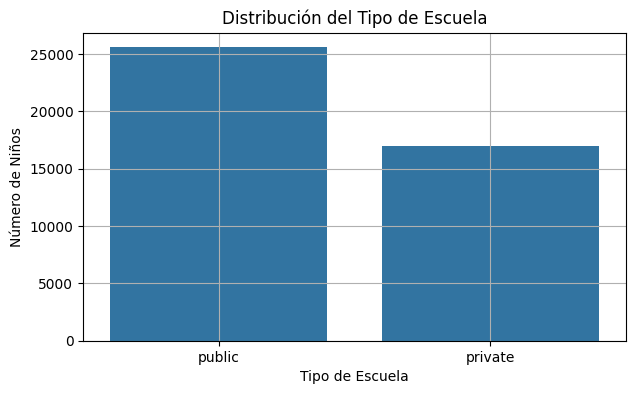

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='ch_school_type_label', order=['public', 'private'])
plt.title('Distribución del Tipo de Escuela')
plt.xlabel('Tipo de Escuela')
plt.ylabel('Número de Niños')
plt.grid(True)
plt.show()

La mayoría de los niños están en instituciones públicas, lo cual es completamente lógico y esperado en la mayoría de contextos nacionales, especialmente en regiones de enfoque del estudio.

Aun así, un 40% aprox. está en escuelas privadas, lo que indica que hay un segmento considerable con acceso a instituciones privadas. Posible relación futura con mayor acceso a internet, continuidad educativa o más apoyo durante la pandemia.

### **Distribución de `ch_situation` (situación escolar actual, mayo - junio 2021)**

In [13]:
# Mapeo a etiquetas legibles
mapa_ch_situation = {
    0: 'not_in_school',
    1: 'in_person',
    2: 'remote',
    3: 'hybrid'
}

df['ch_situation_label'] = df['ch_situation'].map(mapa_ch_situation)

print("Distribución de situación educativa actual:")
print(df['ch_situation_label'].value_counts())

Distribución de situación educativa actual:
ch_situation_label
in_person        19204
remote           16172
hybrid            4450
not_in_school     2774
Name: count, dtype: int64


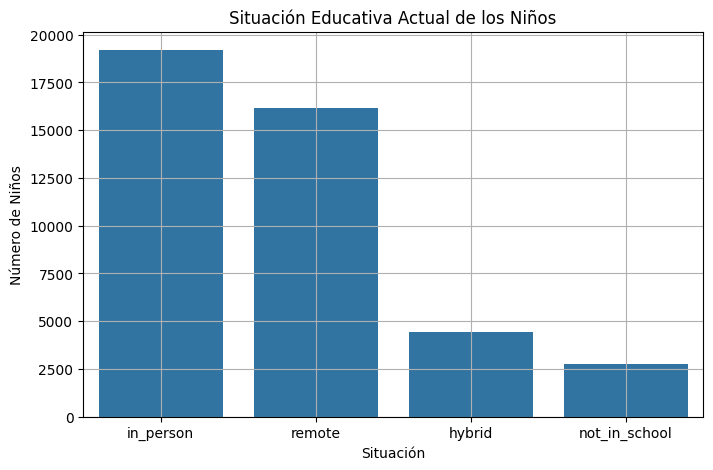

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='ch_situation_label', order=['in_person', 'remote', 'hybrid', 'not_in_school'])
plt.title('Situación Educativa Actual de los Niños')
plt.xlabel('Situación')
plt.ylabel('Número de Niños')
plt.grid(True)
plt.show()

La mayoría está actualmente en clases presenciales, lo cual puede indicar una transición al regreso físico a las aulas.

Le sigue la modalidad remota, esto es muy relevante para investigar:
- Acceso a internet,
- Necesidad de apoyo escolar,
- Continuidad del aprendizaje en contextos vulnerables.

La modalidad híbrida puede ser una alternativa de adaptación, con un porcentaje bajo.

El grupo que no regresó a la escuela es un grupo crítico. Aquí podríamos enfocar la predicción de riesgo de abandono educativo, o estudiar barreras para la continuidad escolar.

### **Distribución de `geography` (ubicación espacial de residencia)**

In [15]:
print(df['geography'].unique())

[ 1  2  3 99]


In [16]:
# Diccionario de mapeo
mapa_geography = {
    1: 'center-metropolitan',
    2: 'suburban',
    3: 'rural',
    99: 'not_available'
}

df['geography_label'] = df['geography'].map(mapa_geography)

print("Distribución de ubicación del hogar:")
print(df['geography_label'].value_counts())

Distribución de ubicación del hogar:
geography_label
center-metropolitan    18207
rural                  12200
suburban               12138
not_available             55
Name: count, dtype: int64


C:\Users\andy-\AppData\Local\Temp\ipykernel_2560\2215991940.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_geo.index, y=conteo_geo.values, palette='Blues_d')


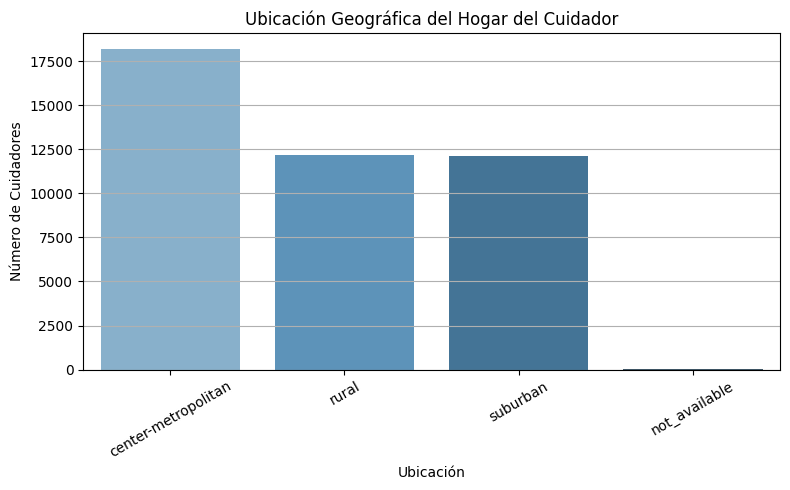

In [17]:
conteo_geo = df['geography_label'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=conteo_geo.index, y=conteo_geo.values, palette='Blues_d')
plt.title('Ubicación Geográfica del Hogar del Cuidador')
plt.xlabel('Ubicación')
plt.ylabel('Número de Cuidadores')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

La mayoría de cuidadores vive en zonas metropolitanas dado que las ciudades concentran más población y más servicios escolares.

Suburbios y áreas rurales están casi igualados, esto nos indica una distribución bastante equilibrada entre zonas no urbanas.

Las entradas no disponibles no afectan al estudio, así que dejaremos dichos valores por ahora.

### **Distribución de `financial_situation` (situación financiera del cuidador)**

In [18]:
# Mapeo a etiquetas
mapa_financial = {
    1: 'ropa_1vez_al_año',
    2: 'solo_gastos_regulares',
    3: 'solo_comida',
    4: 'todo_y_ahorro',
    5: 'ni_comida',
    6: 'ropa_básica',
    7: 'todo_sin_ahorro',
    88: 'no_responde',
    99: 'no_disponible'
}

df['financial_label'] = df['financial_situation'].map(mapa_financial)

print("Distribución de situación económica:")
print(df['financial_label'].value_counts())

Distribución de situación económica:
financial_label
ni_comida                10978
solo_comida               8230
solo_gastos_regulares     6978
no_disponible             4849
todo_y_ahorro             4597
ropa_básica               4044
todo_sin_ahorro           2913
ropa_1vez_al_año            11
Name: count, dtype: int64


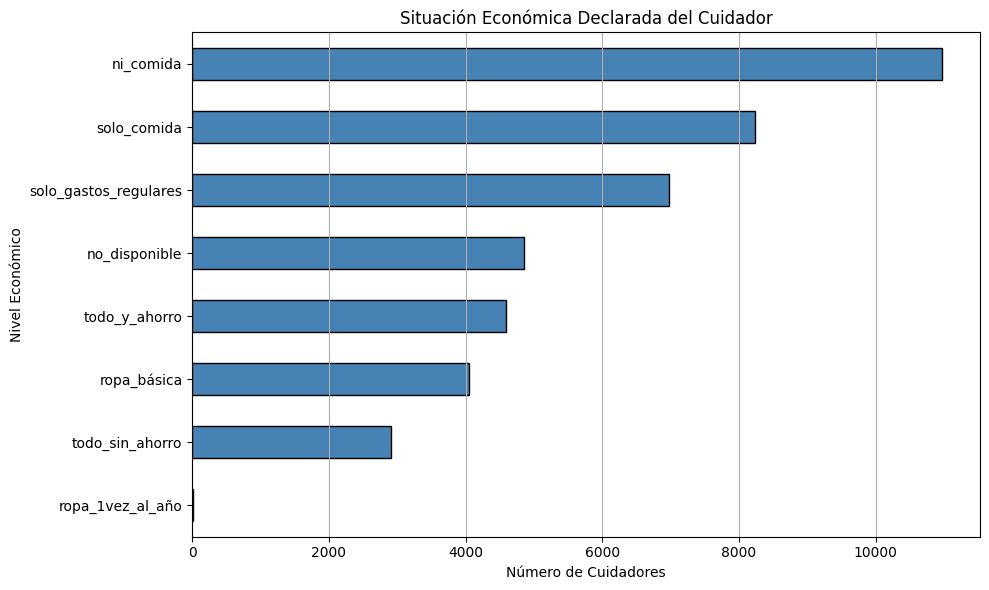

In [19]:
conteo_financiero = df['financial_label'].value_counts().sort_values()

plt.figure(figsize=(10,6))
conteo_financiero.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Situación Económica Declarada del Cuidador')
plt.xlabel('Número de Cuidadores')
plt.ylabel('Nivel Económico')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


La mayoría de cuidadores reportan condiciones de subsistencia: "ni_comida", "solo_comida" y "solo_gastos_regulares". Esto refleja una condición de alta vulnerabilidad económica.

El otro grupo de cuidadores reportan comodidad con ahorros (todo_y_ahorro). Este es el grupo potencialmente menos afectado por barreras económicas educativas.

Los casos sin respuesta o no disponibles se mantienen como categoría separada, para evitar pérdida de información o imputaciones sesgadas.

### **Distribución de `education` (nivel más alto de educación completado por el cuidador)**

In [20]:
# Mapeo a etiquetas
mapa_education = {
    1: 'no_formal',
    3: 'primaria_incompleta',
    4: 'primaria_completa',
    5: 'secundaria_incompleta',
    6: 'secundaria_completa',
    7: 'universidad_incompleta',
    8: 'universidad_completa',
    9: 'postgrado',
    10: 'religiosa',
    11: 'tecnica',
    12: 'alfabetizacion',
    13: 'otro',
    14: 'no_sabe',
    15: 'no_responde',
    99: 'no_disponible'
}

df['education_label'] = df['education'].map(mapa_education)

print("Distribución del nivel educativo del cuidador:")
print(df['education_label'].value_counts())

Distribución del nivel educativo del cuidador:
education_label
no_sabe                   10472
religiosa                  8947
otro                       7198
postgrado                  3647
alfabetizacion             3127
no_responde                1893
tecnica                    1882
universidad_completa       1701
universidad_incompleta     1327
no_formal                  1193
no_disponible              1163
secundaria_incompleta        24
primaria_incompleta          19
secundaria_completa           4
primaria_completa             3
Name: count, dtype: int64


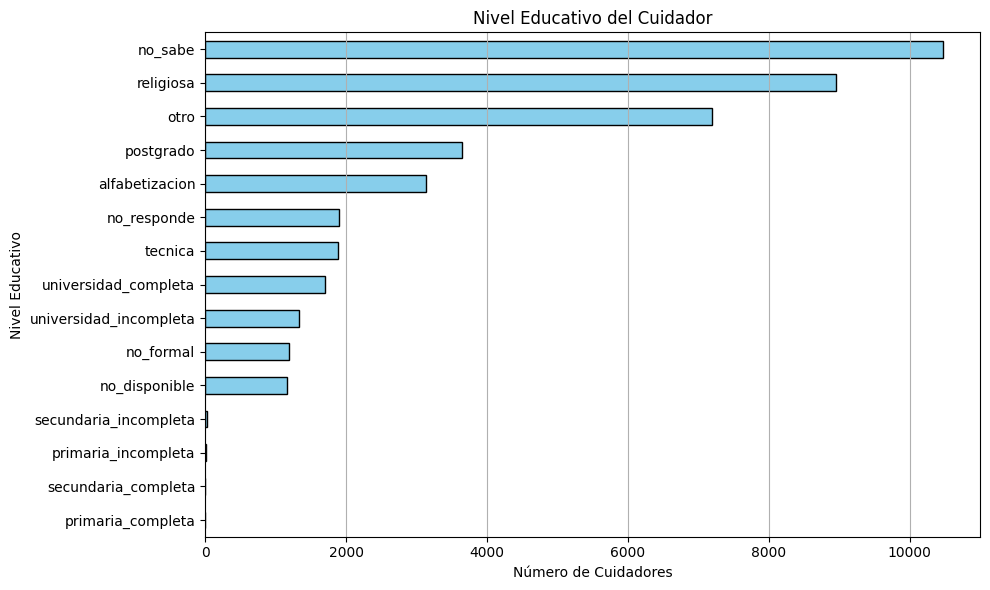

In [21]:
conteo_educacion = df['education_label'].value_counts()

plt.figure(figsize=(10,6))
conteo_educacion.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Nivel Educativo del Cuidador')
plt.xlabel('Número de Cuidadores')
plt.ylabel('Nivel Educativo')
plt.grid(axis='x')
plt.tight_layout()
plt.show()


La categoría más alta es "No sabe". Más de 10,000 personas no saben su nivel educativo exacto o cómo categorizarlo. Esto podría reflejar baja escolarización, informalidad educativa o barreras cognitivas/contextuales.

Muchos marcaron "religiosa" u "otro". La opción religiosa puede haber sido seleccionada en regiones con sistemas no formales. “Otro” también sugiere que la clasificación no se adapta del todo al contexto local.

Aproximadamente 3000 personas con formación técnica o universitaria. Muestra un grupo más educado que podría analizarse por separado para ver impacto en modalidad escolar de los hijos.

Muy pocos registros con educación básica clara (primaria/secundaria). Esto podría ser una debilidad del diseño de la pregunta, o una tendencia de los encuestados a agrupar en categorías alternativas.

### **Distribución de `employment_status` (situación laboral de empleo)**

In [22]:
print(df['employment_status'].unique())

[12 14 17 15 11  0 20 21 16  4 22  3  7  2 99  5  1]


In [23]:
# Mapeo a etiquetas legibles
mapa_empleo = {
    1: 'empleado_ft',
    11: 'empleado_ft',
    2: 'empleado_pt',
    12: 'empleado_pt',
    3: 'autoempleado',
    4: 'estudiante_trabaja',
    14: 'estudiante_trabaja',
    5: 'solo_estudiante',
    15: 'solo_estudiante',
    6: 'jubilado',
    16: 'jubilado',
    7: 'desempleado',
    17: 'desempleado',
    20: 'comunidad',
    21: 'labores_domesticas',
    22: 'incapacitado',
    0: 'ninguna_opcion',
    99: 'no_disponible'
}

df['employment_label'] = df['employment_status'].map(mapa_empleo)

print("Distribución de situación laborarl del cuidador:")
print(df['employment_label'].value_counts())

Distribución de situación laborarl del cuidador:
employment_label
solo_estudiante       13032
empleado_ft           11485
desempleado            6032
empleado_pt            5524
estudiante_trabaja     3374
labores_domesticas     1383
ninguna_opcion         1030
jubilado                334
incapacitado            189
comunidad               154
no_disponible            55
autoempleado              8
Name: count, dtype: int64


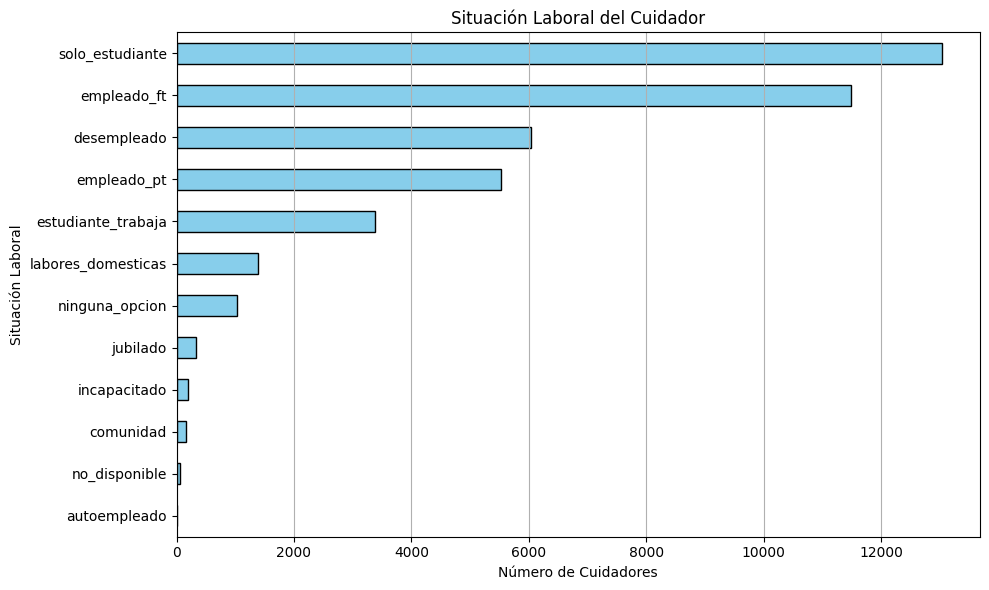

In [24]:
conteo_empleo = df['employment_label'].value_counts()
plt.figure(figsize=(10,6))
conteo_empleo.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Situación Laboral del Cuidador')
plt.xlabel('Número de Cuidadores')
plt.ylabel('Situación Laboral')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

Perfil dominante: cuidadores que son estudiantes. Puede deberse a que algunos cuidadores sean hermanos mayores o tutores jóvenes, o que los encuestados incluyeron personas jóvenes como figura de cuidado temporal.

Más de 11000 con empleo tiempo completo. Muestra una población también económicamente activa.

Cerca de 6000 desempleados más de 1300 en labores domésticas. Este grupo vulnerable puede tener relación con dificultades de acceso educativo.

Pocas personas declararon ser autoempleadas o jubiladas. Solo 8 cuidadores como autoempleados y 334 como jubilados.

### **Guardar datos (se crearon nuevas columnas)**

In [25]:
ruta_guardado = '../data/datos_limpios_univariado.csv'
df.to_csv(ruta_guardado, index=False)

print(f"Dataset limpio guardado exitosamente en {ruta_guardado}")

Dataset limpio guardado exitosamente en ../data/datos_limpios_univariado.csv
